# Data storytelling notebook 3/3
Purpose: Tell the story of the mood changes in music with the seasons globaly.
Dataset: Using our `silver_spotify_daily`-table that spans from 2023/10-18 - 2025-06-11

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
# Konstanter
DB_PATH = "../data/music_warehouse.duckdb"

# Uppkoppling mot DB
con = duckdb.connect(DB_PATH)

In [2]:
# Göra en query för att hämta snitt-glädjen(VALENCE) per vecka
query_mood = """
SELECT  
    date_trunc('week', CAST(snapshot_date AS DATE)) AS week,
    AVG(valence) AS avg_valence,
    AVG(danceability) AS avg_danceability
FROM silver_spotify_daily
GROUP BY 1
ORDER BY 1
"""

df_mood = con.execute(query_mood).df()
con.close()

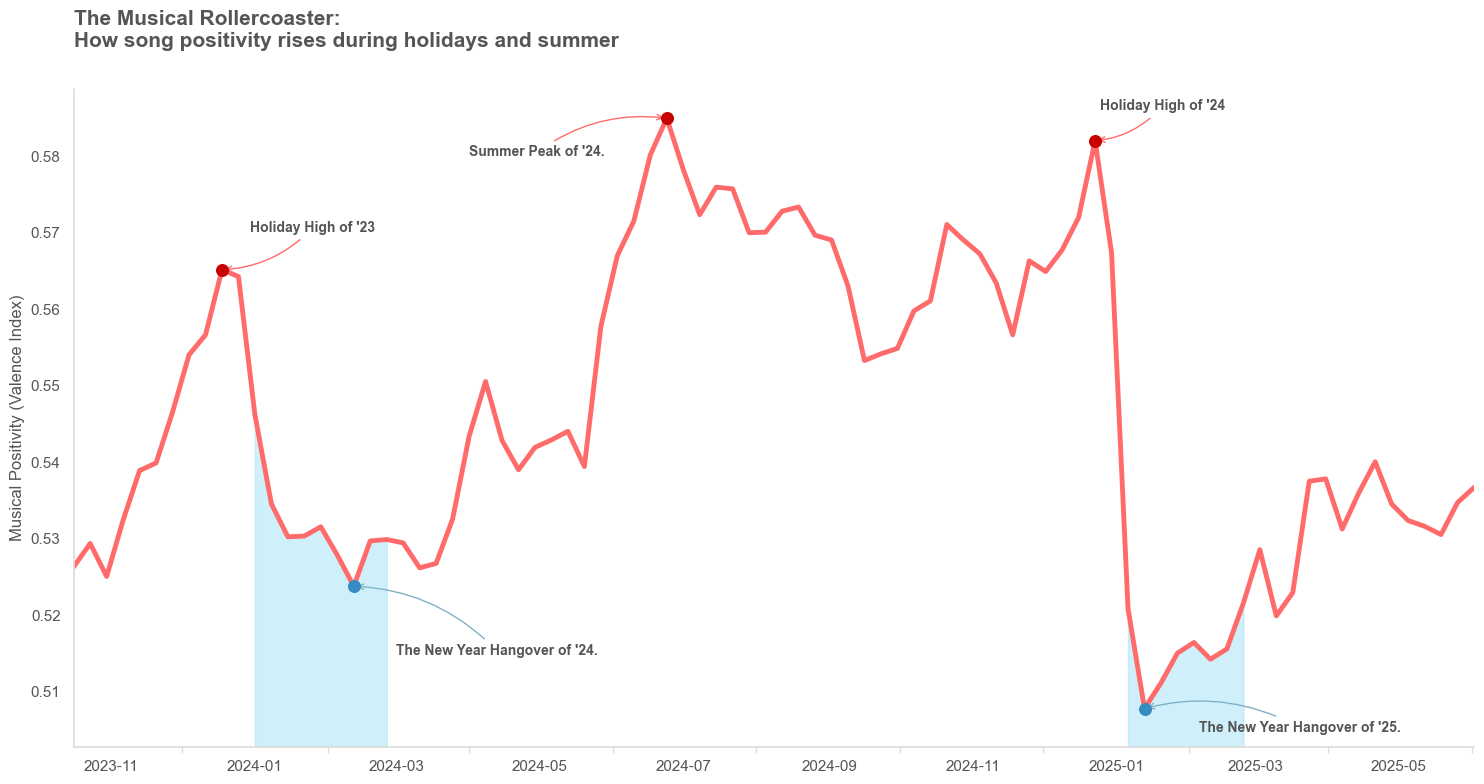

In [ ]:
# Förbered datan
df_plot = df_mood.iloc[:-1].copy()
df_plot["week"] = pd.to_datetime(df_plot["week"])

# Grunsinställningar för plottens layout
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(15, 8))

# Ritar linje för Valence(Glädje). Använder en varm färg för att representera sommar och energi
sns.lineplot(
    data=df_plot, x="week", y="avg_valence", color="#FF6B6B", linewidth=3.5, ax=ax
)

# Sätt en fast botten på Y-axeln (lite under det lägsta värdet i datan)
y_min = df_plot["avg_valence"].min() - 0.005
ax.set_ylim(bottom=y_min)


# ====================================================
# STORYTELLING "isblå/glaciär och kall skuggning" under kurvan
# ====================================================
# Sätt en fast botten på Y-axeln (lite under det lägsta värdet i datan)
y_min = df_plot["avg_valence"].min() - 0.005
ax.set_ylim(bottom=y_min)

mask_jan_24 = (df_plot["week"] >= "2024-01-01") & (df_plot["week"] <= "2024-02-28")
mask_jan_25 = (df_plot["week"] >= "2025-01-01") & (df_plot["week"] <= "2025-02-28")

ax.fill_between(
    df_plot["week"],
    y_min,
    df_plot["avg_valence"],
    where=mask_jan_24,
    color="#A1E3F7",
    alpha=0.5,
    zorder=0,
)
ax.fill_between(
    df_plot["week"],
    y_min,
    df_plot["avg_valence"],
    where=mask_jan_25,
    color="#A1E3F7",
    alpha=0.5,
    zorder=0,
)


# ==================================================
# ANNOTERINGAR (Dynamisk Peak Finder via funktioner)
# ==================================================

# En funktion som hittar den EXAKTA peaken/dippen för att inte gissa
def get_exact_point(df, start_date, end_date, find_max=True):
    """
    Searches through a specific time period and returns 
    (Date, Y value) for top or bottom."""
    temp_df = df[(df["week"] >= start_date) & (df["week"] <= end_date)]
    if find_max:
        target_y = temp_df["avg_valence"].max()
    else:
        target_y = temp_df["avg_valence"].min()

    # Hitta datumet som matchar exakt max och minimum värde
    target_x = temp_df[temp_df["avg_valence"] == target_y]["week"].iloc[0]
    return target_x, target_y


# 1) CHRISTMAS PEAK 2023
x_xmas23, y_xmas23 = get_exact_point(df_plot, "2023-12-01", "2023-12-31", find_max=True)
plt.scatter(x_xmas23, y_xmas23, color="#C70000", s=70, zorder=5)
plt.annotate(
    "Holiday High of '23",
    xy=(x_xmas23, y_xmas23),
    xytext=(pd.to_datetime("2023-12-30"), y_xmas23 + 0.005),  # Text ovanför/vänster
    arrowprops=dict(
        facecolor="#FF6B6B",
        edgecolor="#FF6B6B",
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.2",
    ),
    fontsize=10,
    color="#555555",
    fontweight="bold",
)

# 2) HANGOVER DIP 2024 
x_dip24, y_dip24 = get_exact_point(df_plot, "2024-01-01", "2024-02-28", find_max=False)
plt.scatter(x_dip24, y_dip24, color="#368bc1", s=70, zorder=5)
plt.annotate(
    "The New Year Hangover of '24.",
    xy=(x_dip24, y_dip24),
    xytext=(pd.to_datetime("2024-03-01"), y_min + 0.012),  # Text nere i glaciären
    arrowprops=dict(
        facecolor="#81b2c4",
        edgecolor="#81b2c4",
        arrowstyle="->",
        connectionstyle="arc3,rad=0.2",
    ),
    fontsize=10,
    color="#555555",
    fontweight="bold",
)

# 3) SUMMER PEAK 2024 
x_sum24, y_sum24 = get_exact_point(df_plot, "2024-06-01", "2024-08-31", find_max=True)
plt.scatter(x_sum24, y_sum24, color="#C70000", s=70, zorder=5)
plt.annotate(
    "Summer Peak of '24.",
    xy=(x_sum24, y_sum24),
    xytext=(pd.to_datetime("2024-04-01"), y_sum24 - 0.005),
    arrowprops=dict(
        facecolor="#FF6B6B",
        edgecolor="#FF6B6B",
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.2",
    ),
    fontsize=10,
    color="#555555", 
    fontweight="bold",
)

# 4) CHRISTMAS PEAK 2024 
x_xmas24, y_xmas24 = get_exact_point(df_plot, "2024-12-01", "2024-12-31", find_max=True)
plt.scatter(x_xmas24, y_xmas24, color="#C70000", s=70, zorder=5)
plt.annotate(
    "Holiday High of '24",
    xy=(x_xmas24, y_xmas24),
    xytext=(pd.to_datetime("2024-12-25"), y_xmas24 + 0.004),
    arrowprops=dict(
        facecolor="#FF6B6B",
        edgecolor="#FF6B6B",
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.2",
    ),
    fontsize=10,
    color="#555555",
    fontweight="bold",
)

# 5) HANGOVER DIP 2025 
x_dip25, y_dip25 = get_exact_point(df_plot, "2025-01-01", "2025-02-28", find_max=False)
plt.scatter(x_dip25, y_dip25, color="#368BC1", s=70, zorder=5)
plt.annotate(
    "The New Year Hangover of '25.",
    xy=(x_dip25, y_dip25),
    xytext=(pd.to_datetime("2025-02-05"), y_min + 0.002),
    arrowprops=dict(
        facecolor="#81b2c4", 
        edgecolor="#81b2c4",
        arrowstyle="->",
        connectionstyle="arc3,rad=0.2",
    ),
    fontsize=10,
    color="#555555",
    fontweight="bold",
)

# ============================
# DECLUTTERING, spines etc.
# ============================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#dddddd")
ax.spines["bottom"].set_color("#dddddd")

# Ticks och marginalerna
ax.set_xlim(df_plot["week"].min(), df_plot["week"].max())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.tick_params(
    axis="x", which="minor", bottom=True, colors="#dddddd", length=4, direction="out"
)
ax.tick_params(axis="both", which="major", colors="#555555", length=6)
ax.tick_params(axis="y", colors="#555555")

# ===================
# Titel + spara bild
# ===================
plt.title(
    "The Musical Rollercoaster:\nHow song positivity rises during holidays and summer",
    fontsize=15,
    fontweight="bold",
    color="#555555",
    pad=30,
    loc="left",
)

plt.xlabel("")
plt.ylabel("Musical Positivity (Valence Index)", fontsize=12, color="#555555")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("../data/plots/storytelling_graph_holiday_moods.png")
